In [1]:
import pandas as pd

In [2]:
low_mass_central_df = pd.read_parquet ('../../data/low_mass_central_df_annuli_revised.parquet')

In [3]:
# low_mass_central_df

In [4]:
# # calculating star forming efficiency (SFE) and gas fraction 
# # bin_annuli returns the stellar mass, gas mass, and SFRs in log_10 space
# low_mass_central_df['SFE'] = 10**(low_mass_central_df['avg_SFR'] - low_mass_central_df['avg_gas_mass'])
# low_mass_central_df['f_gas'] = 10**(low_mass_central_df['avg_gas_mass'] - low_mass_central_df['avg_s_mass'])

In [5]:
high_mass_central_df = pd.read_parquet ('../../data/high_mass_central_df_annuli_revised.parquet')

In [6]:
# high_mass_central_df

In [7]:
# # calculating star forming efficiency (SFE) and gas fraction 
# # bin_annuli returns the stellar mass, gas mass, and SFRs in log_10 space
# high_mass_central_df['SFE'] = 10**(high_mass_central_df['avg_SFR'] - high_mass_central_df['avg_gas_mass'])
# high_mass_central_df['f_gas'] = 10**(high_mass_central_df['avg_gas_mass'] - high_mass_central_df['avg_s_mass'])

In [8]:
all_centrals_df = pd.concat([low_mass_central_df, high_mass_central_df], ignore_index=True)
# all_centrals_df.to_parquet("all_centrals_df_annuli_final_more_feat.parquet", engine="pyarrow")
# all_centrals_df

In [9]:
# all_centrals_df = pd.read_parquet ('../all_centrals_df_annuli_more_feat.parquet')
# all_centrals_df

In [10]:
all_centrals_df.isna().any().any()

np.False_

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import RobustScaler

# 'BHMass', 'BHCum_QM', 'Mhalo', 'overdens', and 'bulge' are the features wer are testing
all_centrals_df = all_centrals_df.drop(columns=["class", "BH_cumQM", "BH_cumRM", "global_SFRs", "avg_SFR", "avg_gas_mass","gas_mass","Bfld", "veldisp", "BH_AGN", "bulge"])
all_centrals_df.duplicated()


0        False
1        False
2        False
3        False
4        False
         ...  
48571    False
48572    False
48573    False
48574    False
48575    False
Length: 48576, dtype: bool

Fitting 5 folds for each of 10 candidates, totalling 50 fits


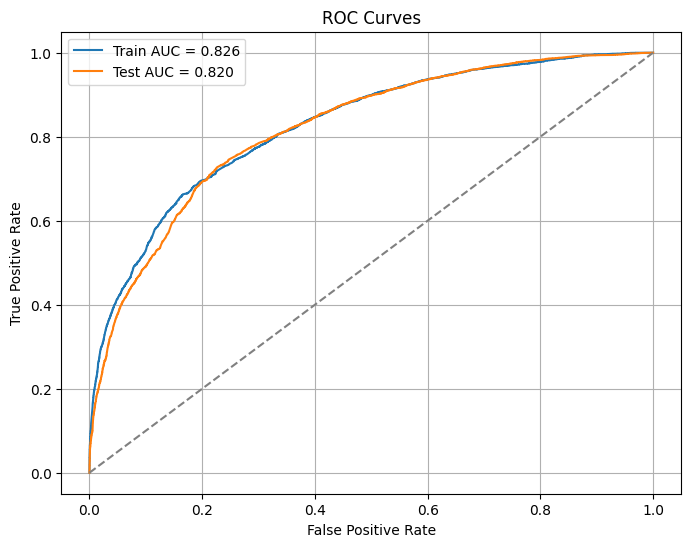

{'n_estimators': 500, 'min_samples_split': 200, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits


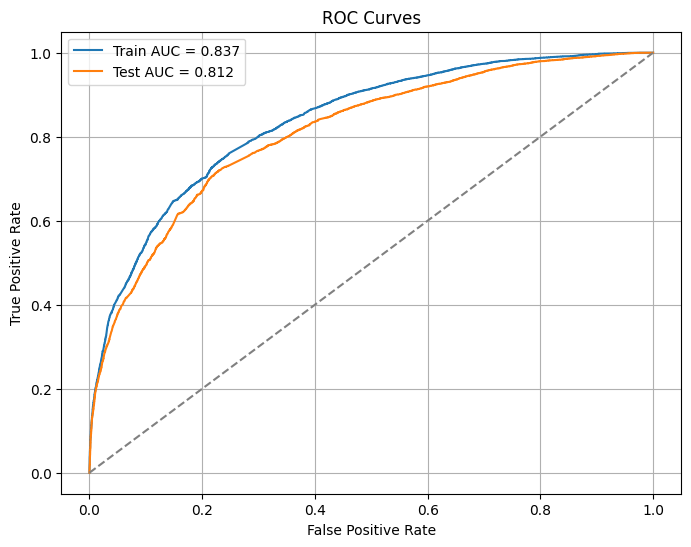

{'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 30, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits


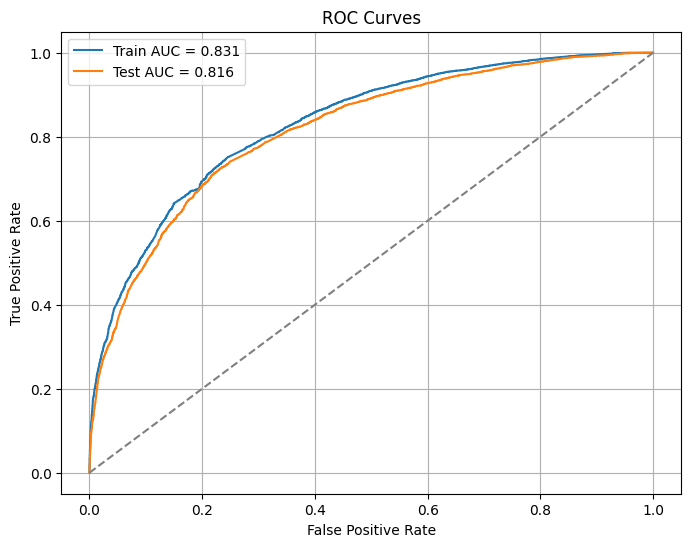

{'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits


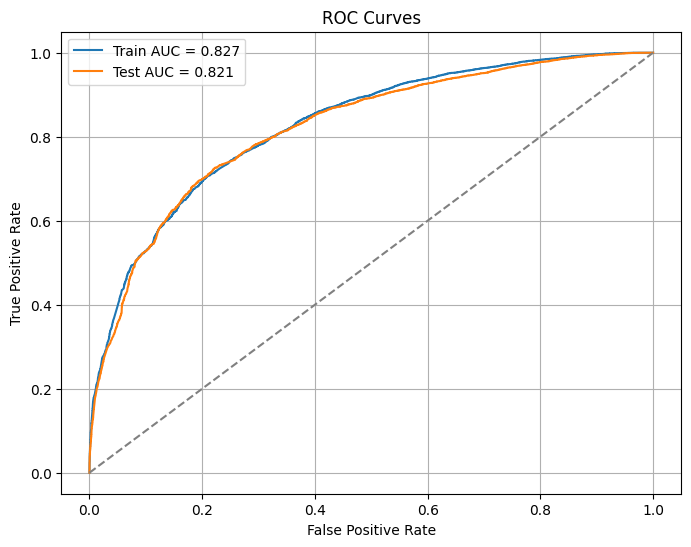

{'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 30, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits


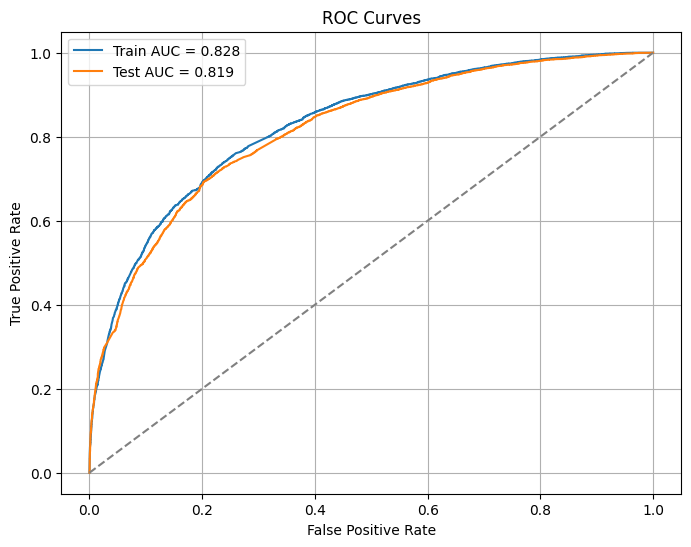

{'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits


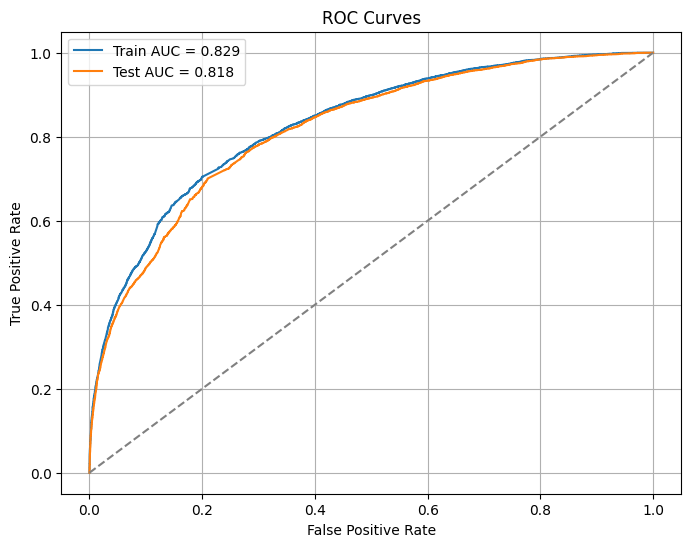

{'n_estimators': 500, 'min_samples_split': 100, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 30, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits


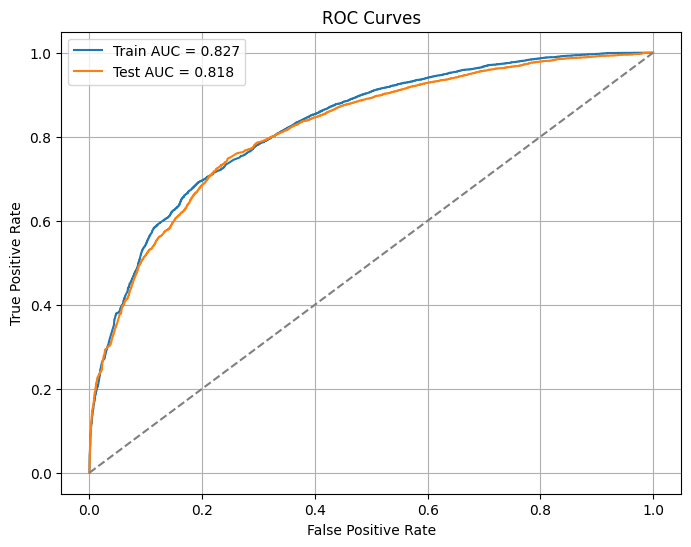

{'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits


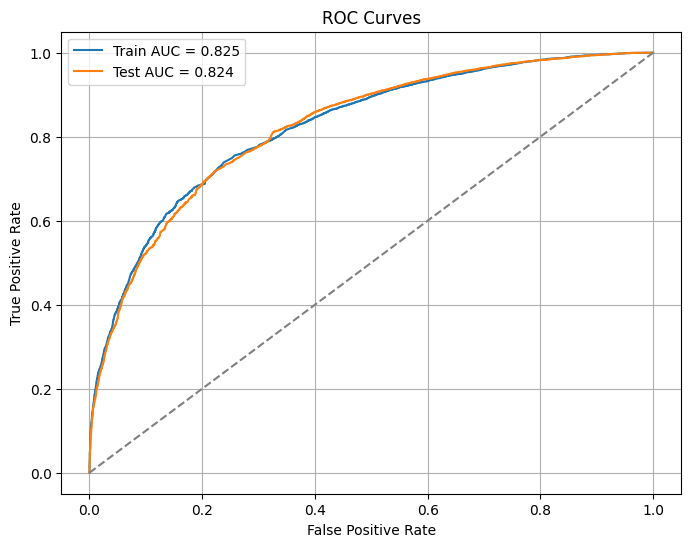

{'n_estimators': 500, 'min_samples_split': 200, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits


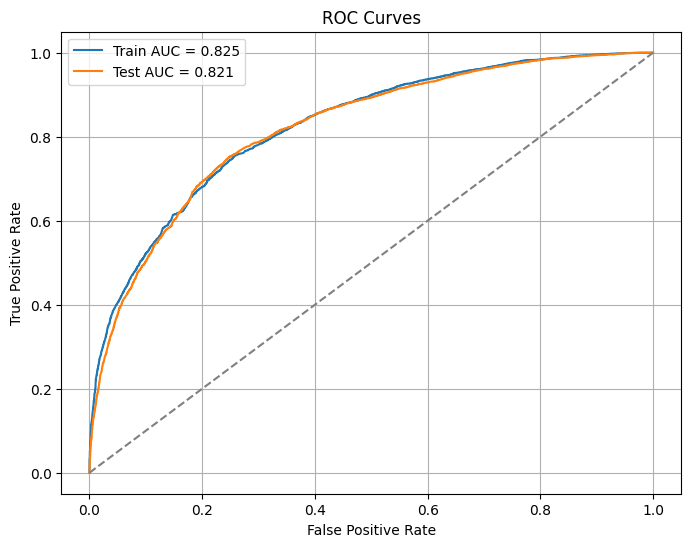

{'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 10, 'class_weight': 'balanced', 'bootstrap': True}
Fitting 5 folds for each of 10 candidates, totalling 50 fits


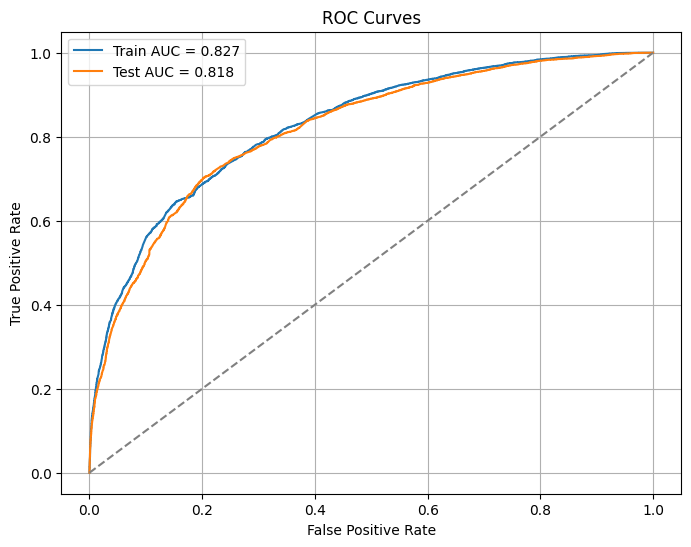

{'n_estimators': 500, 'min_samples_split': 50, 'min_samples_leaf': 500, 'max_features': None, 'max_depth': 20, 'class_weight': 'balanced', 'bootstrap': True}

Average AUC over 10 runs:
Train AUC: Mean = 0.8282, Std = 0.0034
Test AUC:  Mean = 0.8187, Std = 0.0030
Train F1: Mean = 0.6529, Std = 0.0051
Test F1:  Mean = 0.6561, Std = 0.0037


In [12]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold


# splitting galaxies into test/train based on subID
unique_galaxies = np.unique(all_centrals_df['subID'])

train_aucs = []
test_aucs = []
feature_importances_list = []
feature_names = None
train_f1s = []
test_f1s = []


for seed in range(10):
    train_galaxies, test_galaxies = train_test_split(unique_galaxies, test_size=0.5, random_state=seed)

    train_data = all_centrals_df[all_centrals_df['subID'].isin(train_galaxies)]
    test_data = all_centrals_df[all_centrals_df['subID'].isin(test_galaxies)]

    X_train, y_train = train_data.drop(columns=['quenching_vector', 'subID']), train_data['quenching_vector']
    X_test, y_test = test_data.drop(columns=['quenching_vector', 'subID']), test_data['quenching_vector']

    if feature_names is None:
        feature_names = X_train.columns.tolist()
    # scaling
    scaler = RobustScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    param_grid = {
    'n_estimators': [500],  
    'max_depth': [10,20,30],  
    'min_samples_split': [50, 100, 200],  
    'min_samples_leaf': [500, 600, 700],   
    'max_features': [None],  
    'bootstrap': [True],
    'class_weight':['balanced']
    }
    rf = RandomForestClassifier(random_state=seed)
    groups_train = train_data['subID']
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)

    random_search = RandomizedSearchCV(
    estimator=rf, 
    param_distributions=param_grid, 
    n_iter=10,
    cv=cv, 
    scoring='roc_auc',
    n_jobs=-1,
    random_state=seed,
    verbose=2)

    random_search.fit(X_train_scaled, y_train, groups=groups_train)

    best_rf = random_search.best_estimator_

    y_train_prob = best_rf.predict_proba(X_train_scaled)[:, 1]
    y_test_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

    # ROC curves
    plt.figure(figsize=(8,6))
    plt.plot(fpr_train, tpr_train, label=f'Train AUC = {roc_auc_score(y_train, y_train_prob):.3f}')
    plt.plot(fpr_test, tpr_test, label=f'Test AUC = {roc_auc_score(y_test, y_test_prob):.3f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.grid(True)
    plt.show()
    print(random_search.best_params_)

    
    # aucs and feature importance
    train_auc = roc_auc_score(y_train, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    feature_importances_list.append(best_rf.feature_importances_)
    
    train_aucs.append(train_auc)
    test_aucs.append(test_auc)


    y_train_pred = best_rf.predict(X_train_scaled)
    y_test_pred = best_rf.predict(X_test_scaled)

    # f1 scores
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)
    
print("\nAverage AUC over 10 runs:")
print(f"Train AUC: Mean = {np.mean(train_aucs):.4f}, Std = {np.std(train_aucs):.4f}")
print(f"Test AUC:  Mean = {np.mean(test_aucs):.4f}, Std = {np.std(test_aucs):.4f}")
print(f"Train F1: Mean = {np.mean(train_f1s):.4f}, Std = {np.std(train_f1s):.4f}")
print(f"Test F1:  Mean = {np.mean(test_f1s):.4f}, Std = {np.std(test_f1s):.4f}")


=== Average Feature Importances ===
      Feature  Mean Importance   Std Dev
3      BHMass         0.754923  0.017387
1  avg_s_mass         0.129978  0.010283
0   bin_radii         0.042058  0.005961
2      s_mass         0.032629  0.009218
5    overdens         0.020206  0.014600
4       Mhalo         0.020206  0.009005


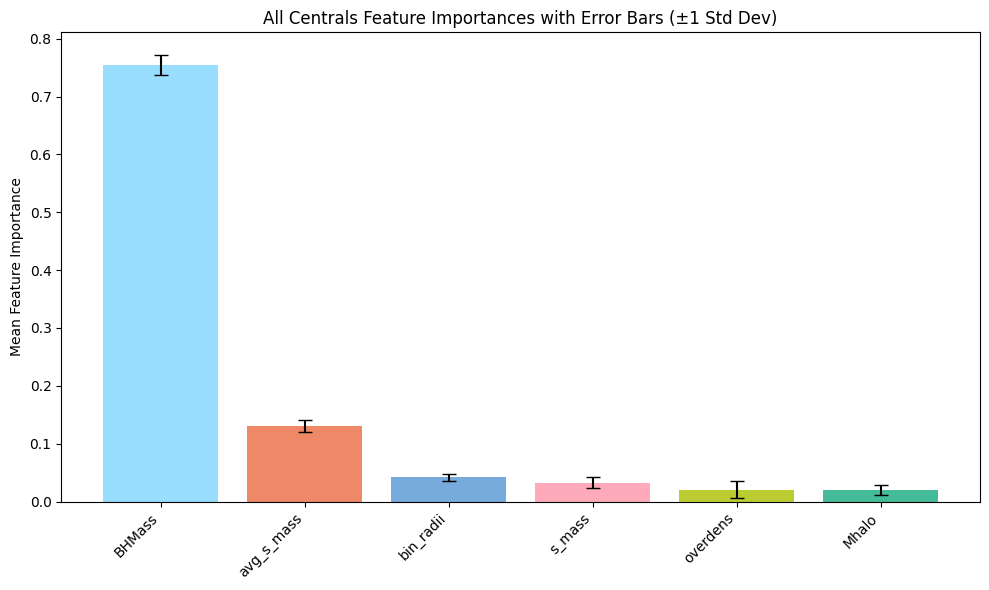

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
feature_colors = {
    'bin_radii': '#77AADD',
    'avg_s_mass': '#EE8866',
#     'Bfld': '#EEDD88',
    # 'veldisp': '#EEDD88',
    's_mass': '#FFAABB',
    'BHMass': '#99DDFF',
    'Mhalo': '#44BB99',
    'overdens': '#BBCC33',
    'bulge': '#AAAA00',
    'BH_AGN': '#DDDDDD',
}

# importances + stds across 10 runs
importances_array = np.array(feature_importances_list)
importance_means = np.mean(importances_array, axis=0)
importance_stds = np.std(importances_array, axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': importance_means,
    'Std Dev': importance_stds
}).sort_values(by='Mean Importance', ascending=False)

print("\n=== Average Feature Importances ===")
print(importance_df)

colors = [feature_colors[feat] for feat in importance_df['Feature']]
# Plot
plt.figure(figsize=(10, 6))
plt.bar(importance_df['Feature'], importance_df['Mean Importance'], yerr=importance_df['Std Dev'], capsize=5, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Mean Feature Importance")
plt.title("All Centrals Feature Importances with Error Bars (±1 Std Dev)")
plt.tight_layout()
plt.show()

In [14]:
# from sklearn.metrics import f1_score
# y_train_pred = best_rf.predict(X_train_scaled)
# y_test_pred = best_rf.predict(X_test_scaled)

# # f1 scores
# train_f1 = f1_score(y_train, y_train_pred)
# test_f1 = f1_score(y_test, y_test_pred)

# print(f"Train F1 Score: {train_f1:.3f}")
# print(f"Test F1 Score: {test_f1:.3f}")

In [15]:
import os
# Define your directory and file name
directory = 'rf_classification_outputs'
filename = 'all_centrals_rf_quenching.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
importance_df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

DataFrame saved to rf_classification_outputs\all_centrals_rf_quenching.csv


In [16]:
train_mean = round(np.mean(train_aucs), 2)
test_mean = round(np.mean(test_aucs), 2)
print(train_mean)
df = pd.DataFrame({
    'Train AUC': [train_mean],
    'Test AUC': [test_mean]
})

print(df)
import os
# Define your directory and file name
directory = 'rf_classification_outputs'
filename = 'all_centrals_rf_quenching_auc.csv'
filepath = os.path.join(directory, filename)

# Create the directory if it doesn't exist
os.makedirs(directory, exist_ok=True)

# Save the DataFrame
df.to_csv(filepath, index=False)

print(f'DataFrame saved to {filepath}')

0.83
   Train AUC  Test AUC
0       0.83      0.82
DataFrame saved to rf_classification_outputs\all_centrals_rf_quenching_auc.csv
